# Issue Pattern & Root Cause Explorer
**Author:** Gina Nguyen 

**Goal:** What are the most common complaint themes and how are they shifting?

- **Data:** CFPB complaints in DuckDB (`database/cfpb_complaints.duckdb`), built from `landing/cfpb_complaints/` → dlt → dbt marts.
- **Purpose:** to explore issue-focused metrics and get query patterns for visualization of Treemap, Heatmap, small multiples, state map, filters.

## 1. Connect to the database

In [ ]:
import os
import duckdb
import pandas as pd

cwd = os.getcwd()
db_path = None
for base in [cwd, os.path.dirname(cwd)]:
    p = os.path.join(base, "database", "cfpb_complaints.duckdb")
    if os.path.exists(p):
        db_path = p
        break
if not db_path:
    raise FileNotFoundError(
        f"DuckDB not found. Looked in {cwd} and parent. Run the pipeline and dbt first."
    )

conn = duckdb.connect(db_path, read_only=True)
print(f"Connected to {db_path}")

Connected to /Users/ninhgiangnguyen/local_warehouse_pipeline/database/cfpb_complaints.duckdb


## 2. Treemap — Issue frequency

In [11]:
treemap_df = conn.execute("""
    SELECT issue, total_complaints AS complaint_count
    FROM marts.dim_issues
    WHERE sub_issue IS NULL
    ORDER BY total_complaints DESC
""").df()
treemap_df.head(15)

,issue,complaint_count
0,Managing an account,70702.0
1,Incorrect information on your report,51548.0
2,Improper use of your report,40341.0
3,Problem with a purchase shown on your statement,35364.0
4,Problem with a company's investigation into an...,17641.0
5,Closing an account,17175.0
6,Getting a credit card,15170.0
7,"Other features, terms, or problems",14658.0
8,Problem with a lender or other company chargin...,13588.0
9,Attempts to collect debt not owed,11526.0


## 3. Heatmap — Issue × Product

In [12]:
heatmap_df = conn.execute("""
    WITH agg AS (
        SELECT issue, product, COUNT(*) AS complaint_count
        FROM marts.fct_complaints
        WHERE issue IS NOT NULL AND product IS NOT NULL
        GROUP BY issue, product
    ),
    total AS (SELECT SUM(complaint_count) AS t FROM agg)
    SELECT agg.issue, agg.product, agg.complaint_count,
           ROUND(100.0 * agg.complaint_count / total.t, 2) AS pct_total
    FROM agg CROSS JOIN total
    ORDER BY complaint_count DESC
""").df()
heatmap_df.head(20)

,issue,product,complaint_count,pct_total
0,Managing an account,Checking or savings account,70702,17.03
1,Incorrect information on your report,Credit reporting or other personal consumer re...,38974,9.39
2,Improper use of your report,Credit reporting or other personal consumer re...,32629,7.86
3,Problem with a purchase shown on your statement,Credit card,29866,7.19
4,Closing an account,Checking or savings account,17175,4.14
5,Problem with a company's investigation into an...,Credit reporting or other personal consumer re...,14860,3.58
6,Problem with a lender or other company chargin...,Checking or savings account,13588,3.27
7,Getting a credit card,Credit card,12431,2.99
8,"Other features, terms, or problems",Credit card,12372,2.98
9,Attempts to collect debt not owed,Debt collection,11526,2.78


## 4. Small multiples — Time-series by issue

In [13]:
timeseries_df = conn.execute("""
    SELECT
        issue,
        complaint_month_date AS month_date,
        COUNT(*) AS complaint_count
    FROM marts.fct_complaints
    WHERE issue IS NOT NULL AND complaint_month_date IS NOT NULL
    GROUP BY issue, complaint_month_date
    ORDER BY issue, month_date
""").df()
timeseries_df.head(20)

,issue,month_date,complaint_count
0,Advertising,2023-01-01,1
1,Advertising,2023-02-01,4
2,Advertising,2023-04-01,1
3,Advertising,2023-05-01,1
4,Advertising,2023-06-01,1
5,Advertising,2023-07-01,2
6,Advertising,2023-08-01,3
7,Advertising,2023-09-01,1
8,Advertising,2023-10-01,2
9,Advertising,2023-11-01,3


## 5. State map — Issue × State

In [14]:
state_map_df = conn.execute("""
    WITH agg AS (
        SELECT issue, state, COUNT(*) AS complaint_count
        FROM marts.fct_complaints
        WHERE issue IS NOT NULL AND state IS NOT NULL AND state != ''
        GROUP BY issue, state
    ),
    by_issue AS (SELECT issue, SUM(complaint_count) AS issue_total FROM agg GROUP BY issue)
    SELECT agg.issue, agg.state, agg.complaint_count,
           ROUND(100.0 * agg.complaint_count / by_issue.issue_total, 2) AS pct_of_issue
    FROM agg JOIN by_issue ON agg.issue = by_issue.issue
    ORDER BY agg.complaint_count DESC
""").df()
state_map_df.head(20)

,issue,state,complaint_count,pct_of_issue
0,Managing an account,CA,12243,17.48
1,Incorrect information on your report,FL,7245,14.07
2,Managing an account,FL,6907,9.86
3,Managing an account,NY,6463,9.23
4,Managing an account,TX,6382,9.11
5,Problem with a purchase shown on your statement,CA,5978,16.95
6,Incorrect information on your report,CA,5925,11.51
7,Improper use of your report,FL,5395,13.38
8,Incorrect information on your report,TX,4856,9.43
9,Improper use of your report,CA,4490,11.14


## 6. Interactive filters — Detail table

In [15]:
filter_sample = conn.execute("""
    SELECT product, state, complaint_month_date, issue, COUNT(*) AS complaints
    FROM marts.fct_complaints
    WHERE complaint_month_date >= '2024-01-01'
    GROUP BY product, state, complaint_month_date, issue
    ORDER BY complaints DESC
    LIMIT 10
""").df()
filter_sample

,product,state,complaint_month_date,issue,complaints
0,Checking or savings account,TX,2025-01-01,Managing an account,952
1,Checking or savings account,NY,2025-01-01,Managing an account,677
2,Checking or savings account,CA,2025-01-01,Managing an account,573
3,Checking or savings account,FL,2025-01-01,Managing an account,516
4,Checking or savings account,CA,2026-01-01,Managing an account,463
5,Checking or savings account,CA,2025-12-01,Managing an account,428
6,Checking or savings account,CA,2025-07-01,Managing an account,425
7,Checking or savings account,CA,2025-11-01,Managing an account,402
8,Checking or savings account,CA,2025-08-01,Managing an account,371
9,Checking or savings account,CA,2025-10-01,Managing an account,359


## 7. % Disputed per issue (root cause)

In [16]:
dispute_df = conn.execute("""
    SELECT issue, total_complaints, disputed_complaints AS disputed_count, pct_disputed
    FROM marts.dim_issues
    WHERE sub_issue IS NULL
    ORDER BY total_complaints DESC
""").df()
dispute_df.head(15)

,issue,total_complaints,disputed_count,pct_disputed
0,Managing an account,70702.0,NaN,NaN
1,Incorrect information on your report,51548.0,NaN,NaN
2,Improper use of your report,40341.0,NaN,NaN
3,Problem with a purchase shown on your statement,35364.0,NaN,NaN
4,Problem with a company's investigation into an...,17641.0,NaN,NaN
5,Closing an account,17175.0,NaN,NaN
6,Getting a credit card,15170.0,NaN,NaN
7,"Other features, terms, or problems",14658.0,NaN,NaN
8,Problem with a lender or other company chargin...,13588.0,NaN,NaN
9,Attempts to collect debt not owed,11526.0,NaN,NaN


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

## 9. Visualizations (matplotlib / seaborn)

These plots use the DataFrames created above:
- `treemap_df`, `heatmap_df`, `timeseries_df`, `state_map_df`

If you restarted the kernel, run the notebook from the top first.

In [19]:
required = ["treemap_df", "heatmap_df", "timeseries_df", "state_map_df"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing {missing}. Run the earlier query cells first.")

# Make sure dates are datetimes for plotting
if "month_date" in timeseries_df.columns:
    timeseries_df["month_date"] = pd.to_datetime(timeseries_df["month_date"])

### 9.1 Treemap (issue frequency)

If `squarify` is available, we draw a real treemap; otherwise we fall back to a bar chart (still useful for BI validation).

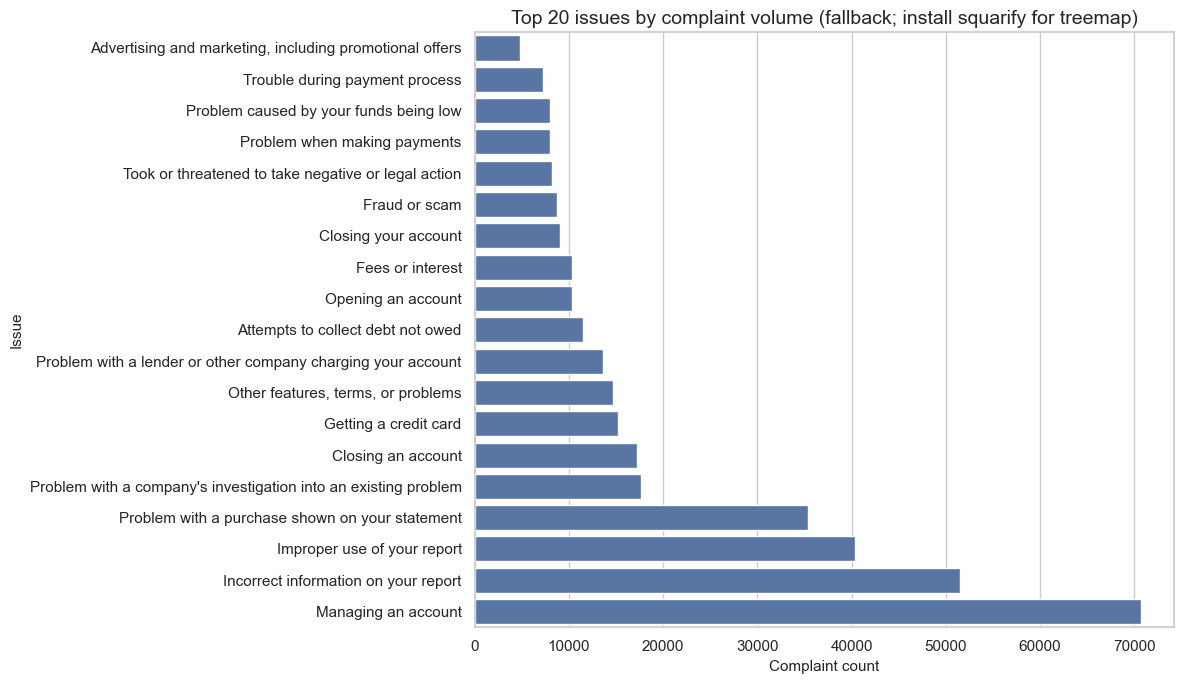

Treemap note: ModuleNotFoundError("No module named 'squarify'")


In [20]:
top_n = 20
plot_df = treemap_df.head(top_n).copy()
plot_df["label"] = plot_df["issue"].astype(str) + "\n" + plot_df["complaint_count"].astype(int).astype(str)

try:
    import squarify  # pip install squarify

    fig, ax = plt.subplots(figsize=(14, 8))
    colors = sns.color_palette("Spectral", n_colors=len(plot_df))
    squarify.plot(
        sizes=plot_df["complaint_count"].tolist(),
        label=plot_df["label"].tolist(),
        color=colors,
        alpha=0.9,
        ax=ax,
        text_kwargs={"fontsize": 9},
    )
    ax.set_title(f"Treemap — Top {top_n} issues by complaint volume")
    ax.axis("off")
    plt.show()
except Exception as e:
    # Fallback if squarify isn't installed
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(
        data=plot_df.sort_values("complaint_count", ascending=True),
        x="complaint_count",
        y="issue",
        ax=ax,
        color=sns.color_palette("deep")[0],
    )
    ax.set_title(f"Top {top_n} issues by complaint volume (fallback; install squarify for treemap)")
    ax.set_xlabel("Complaint count")
    ax.set_ylabel("Issue")
    plt.tight_layout()
    plt.show()

    print("Treemap note:", repr(e))

### 9.2 Heatmap (Issue × Product)

We plot the top issues and products (to keep the grid readable).

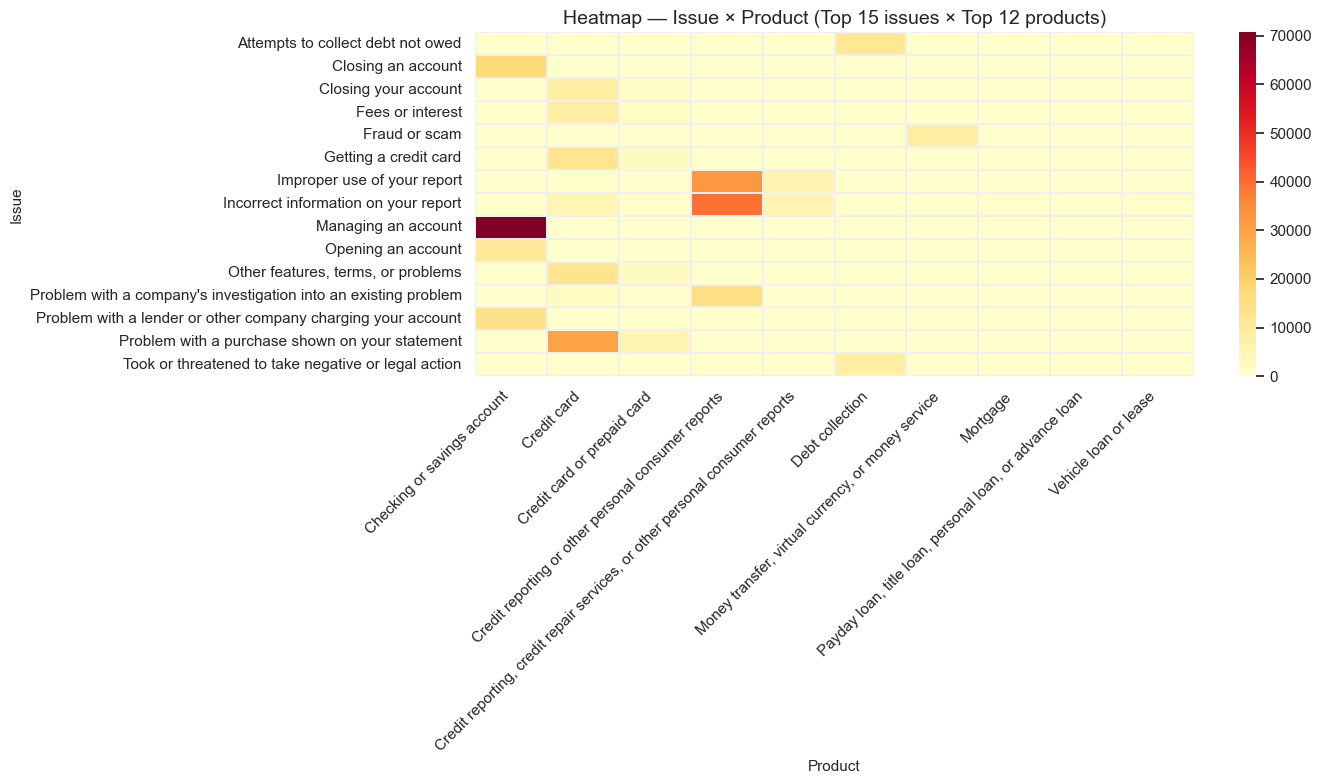

In [21]:
top_issues = 15
top_products = 12

# pick top issues/products by total volume
issue_rank = (
    heatmap_df.groupby("issue", as_index=False)["complaint_count"].sum()
    .sort_values("complaint_count", ascending=False)
    .head(top_issues)
)
product_rank = (
    heatmap_df.groupby("product", as_index=False)["complaint_count"].sum()
    .sort_values("complaint_count", ascending=False)
    .head(top_products)
)

hm = heatmap_df[
    heatmap_df["issue"].isin(issue_rank["issue"]) & heatmap_df["product"].isin(product_rank["product"])
].copy()

pivot = hm.pivot_table(index="issue", columns="product", values="complaint_count", aggfunc="sum", fill_value=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="#f0f0f0", ax=ax)
ax.set_title(f"Heatmap — Issue × Product (Top {top_issues} issues × Top {top_products} products)")
ax.set_xlabel("Product")
ax.set_ylabel("Issue")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 9.3 Small multiples time-series (complaints over time)

We facet by issue for the top issues only, so the grid is readable.

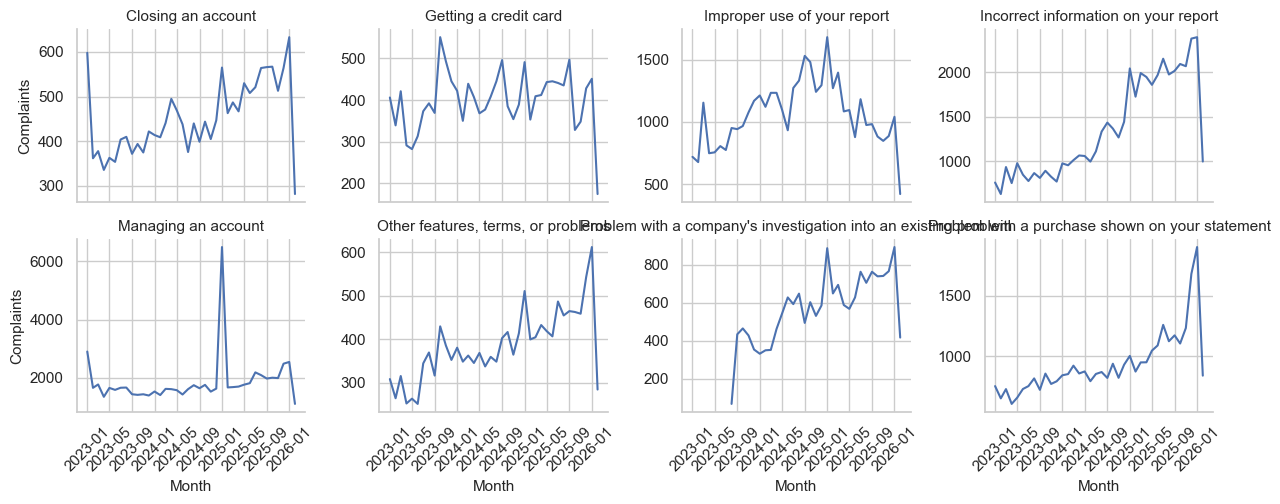

In [22]:
top_k = 8
issue_totals = (
    timeseries_df.groupby("issue", as_index=False)["complaint_count"].sum()
    .sort_values("complaint_count", ascending=False)
    .head(top_k)
)

ts = timeseries_df[timeseries_df["issue"].isin(issue_totals["issue"])].copy()

g = sns.relplot(
    data=ts,
    x="month_date",
    y="complaint_count",
    col="issue",
    col_wrap=4,
    kind="line",
    facet_kws={"sharey": False},
    height=2.6,
    aspect=1.2,
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Month", "Complaints")
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### 9.5 Interactive filters (Product, State, Time)

If `ipywidgets` is installed, you’ll get dropdown/date pickers. If not, set the variables manually and rerun the cell.

In [24]:
def load_monthly_counts(product=None, state=None, start_date=None, end_date=None):
    sql = """
        SELECT complaint_month_date AS month_date, COUNT(*) AS complaint_count
        FROM marts.fct_complaints
        WHERE complaint_month_date IS NOT NULL
    """
    params = []
    if product and product != "(All)":
        sql += " AND product = ?"
        params.append(product)
    if state and state != "(All)":
        sql += " AND state = ?"
        params.append(state)
    if start_date:
        sql += " AND complaint_month_date >= ?"
        params.append(pd.to_datetime(start_date).date())
    if end_date:
        sql += " AND complaint_month_date <= ?"
        params.append(pd.to_datetime(end_date).date())

    sql += " GROUP BY complaint_month_date ORDER BY complaint_month_date"
    return conn.execute(sql, params).df()


def plot_filtered_trend(product="(All)", state="(All)", start_date=None, end_date=None):
    df = load_monthly_counts(product=product, state=state, start_date=start_date, end_date=end_date)
    df["month_date"] = pd.to_datetime(df["month_date"])

    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=df, x="month_date", y="complaint_count", ax=ax)
    ax.set_title(f"Filtered trend — product={product}, state={state}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Complaints")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


# Try widgets; otherwise run once with manual parameters
try:
    import ipywidgets as widgets
    from IPython.display import display

    products = conn.execute(
        "SELECT DISTINCT product FROM marts.fct_complaints WHERE product IS NOT NULL ORDER BY product"
    ).fetchnumpy()["product"].tolist()
    states = conn.execute(
        "SELECT DISTINCT state FROM marts.fct_complaints WHERE state IS NOT NULL AND state != '' ORDER BY state"
    ).fetchnumpy()["state"].tolist()

    product_w = widgets.Dropdown(options=["(All)"] + products, value="(All)", description="Product")
    state_w = widgets.Dropdown(options=["(All)"] + states, value="(All)", description="State")
    start_w = widgets.DatePicker(description="Start")
    end_w = widgets.DatePicker(description="End")

    ui = widgets.HBox([product_w, state_w, start_w, end_w])
    out = widgets.interactive_output(
        plot_filtered_trend,
        {
            "product": product_w,
            "state": state_w,
            "start_date": start_w,
            "end_date": end_w,
        },
    )

    display(ui, out)
except Exception:
    # Manual example (edit parameters and re-run)
    plot_filtered_trend(product="(All)", state="(All)", start_date=None, end_date=None)

ConnectionException: Connection Error: Connection already closed!

In [25]:
# Safe close (won't error if conn is missing/already closed)
try:
    if "conn" in globals() and conn is not None:
        conn.close()
        conn = None
    print("Connection closed.")
except Exception as e:
    print(f"Close skipped: {e}")

Connection closed.
